# E-Commerce Customer Segmentation using RFM and Clustering

## 1. Data Understanding

- **InvoiceNo**: Unique number assigned to each transaction or invoice.  
- **StockCode**: Unique code used to identify each product.  
- **Description**: Product name or brief details.  
- **Category**: Type or category of the product.  
- **Quantity**: Number of units purchased in a transaction.  
- **InvoiceDate**: Date and time when the purchase was made.  
- **UnitPrice**: Cost of a single unit of the product.  
- **CustomerID**: Unique identifier for each customer.  
- **Country**: Customer’s country of residence.  

- **Single Row**: Represents one product purchased by a customer in a specific transaction.  

- **Business Type**: E-commerce / online retail business.  

- **Analysis Focus**: Understanding sales patterns, customer behavior, product performance, and customer segmentation using **RFM analysis and clustering**.  

- **Business Questions Answered**: Which products perform best? Who are the most valuable customers? Which regions generate higher revenue? How can customer segmentation improve marketing strategies?  

- **Business Questions Not Covered**: Profit margins, customer demographics, marketing channel performance, and reasons for customer churn due to limited data availability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('part_1_ecommerce_customer_segmentation.csv')
display(df.head())
display(df.info())
display(df.describe())

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4395 non-null   object 
 1   StockCode    4395 non-null   object 
 2   Description  4328 non-null   object 
 3   Category     4395 non-null   object 
 4   Quantity     4395 non-null   int64  
 5   InvoiceDate  4395 non-null   object 
 6   UnitPrice    4395 non-null   float64
 7   CustomerID   4187 non-null   object 
 8   Country      4395 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 309.2+ KB


None

,Quantity,UnitPrice
count,4395.000000,4395.000000
mean,2.826394,747.081477
std,3.846051,611.134932
min,-50.000000,-2244.520000
25%,1.000000,328.200000
50%,2.000000,544.320000
75%,4.000000,950.470000
max,50.000000,2939.580000


## 2. Data Cleaning

- Remove rows with missing **CustomerID** (required for customer/RFM analysis).  
- Remove rows with missing **Description** (if present).  
- Remove rows with zero or negative **Quantity** (possible returns or incorrect entries).  
- Remove rows with zero or negative **UnitPrice** (invalid pricing records).  
- Remove cancelled invoices (usually marked with **'C'** in **InvoiceNo**).  
- Remove duplicate records.  
- Convert **InvoiceDate** to datetime format.

In [2]:
# Drop missing CustomerID
df = df.dropna(subset=['CustomerID', 'Description'])

# Remove negative/zero quantity and price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove cancelled invoices (if InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Drop duplicates
df = df.drop_duplicates()

# Fix types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Data shape after cleaning: {df.shape}")

Data shape after cleaning: (3848, 9)


## 3. Feature Engineering (RFM)

- **Total Revenue**: Quantity * UnitPrice
- **Recency**: Days since last purchase (relative to the max date in the dataset + 1 day).
- **Frequency**: Total number of unique invoices per customer.
- **Monetary**: Total revenue per customer.

In [3]:
# Create Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Snapshot date for Recency
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Aggregation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum',
    'Quantity': 'sum',
    'StockCode': 'nunique',
    'Country': 'first' # Assuming one country per customer
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Revenue': 'Monetary',
    'Quantity': 'TotalQuantity',
    'StockCode': 'UniqueProducts'
}, inplace=True)

rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Country,AvgOrderValue
0,C10001,117,3,22885.81,63,8,India,7628.603333
1,C10003,33,1,12061.04,10,3,United Kingdom,12061.040000
2,C10004,40,2,10579.97,16,5,United Kingdom,5289.985000
3,C10005,297,2,14154.57,17,7,Germany,7077.285000
4,C10006,31,3,27389.29,27,8,India,9129.763333


## 4. Exploratory Data Analysis

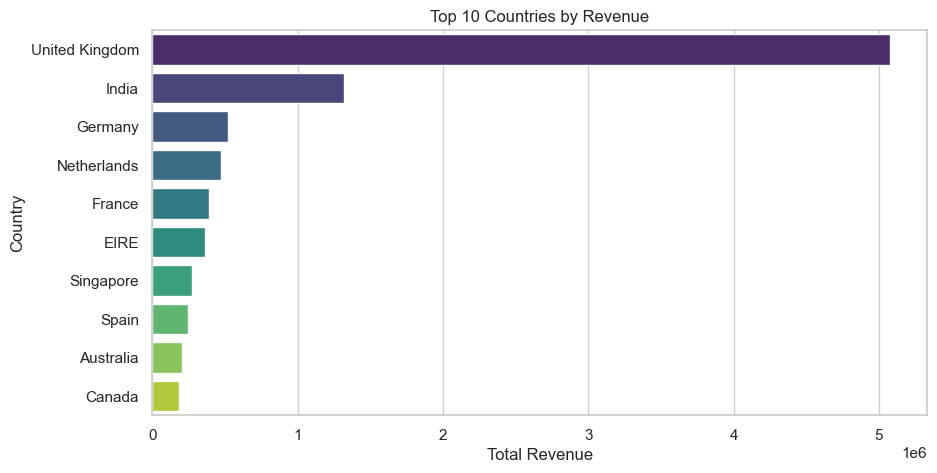

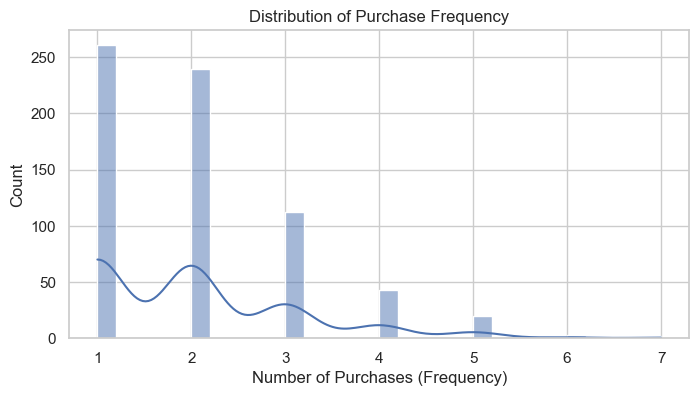

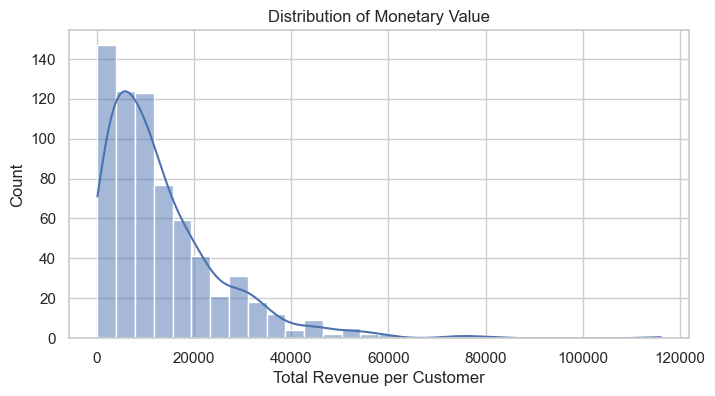

In [4]:
# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Country with highest sales
plt.figure(figsize=(10,5))
country_sales = rfm.groupby('Country')['Monetary'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_sales.values, y=country_sales.index, palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.show()

# 2. Distribution of Frequency
plt.figure(figsize=(8,4))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Distribution of Purchase Frequency')
plt.xlabel('Number of Purchases (Frequency)')
plt.show()

# 3. Distribution of Monetary
plt.figure(figsize=(8,4))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Distribution of Monetary Value')
plt.xlabel('Total Revenue per Customer')
plt.show()

### Chart Interpretations

1. **Top Countries by Revenue (Bar Chart)**: Shows the countries contributing the highest revenue. Usually, the main business country (such as UK or EIRE) generates most sales.  

2. **Purchase Frequency (Histogram)**: Right-skewed distribution where most customers make only a few purchases, while a small number of customers purchase very frequently.  

3. **Monetary Value (Histogram)**: Right-skewed distribution showing that most customers spend lower amounts, while a small group of high-spending customers contribute a larger share of revenue.

## 5. Customer Segmentation Using K-Means

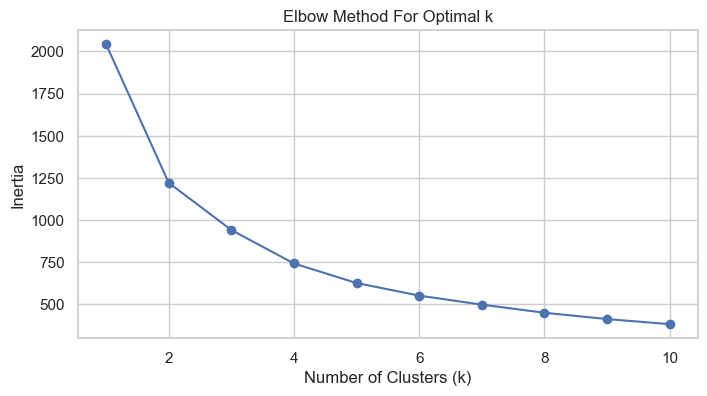

In [5]:
# Select RFM features
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]

# Log Transform to handle skewness (optional but recommended for RFM)
X_log = np.log1p(X)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Elbow method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

### Plot Interpretation 

**Elbow Method (Line Chart)**: By plotting the inertia (within-cluster sum of squares) against k, we look for the "elbow," or the point where adding another cluster diminishes the rate of inertia drop. This usually occurs around k=3, 4, or 5 in RFM clustering.

Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0         18.33      1.84  10515.11   101
1        167.97      1.65  12271.42   247
2        176.29      1.10   2655.53   155
3         77.98      3.47  26013.49   178

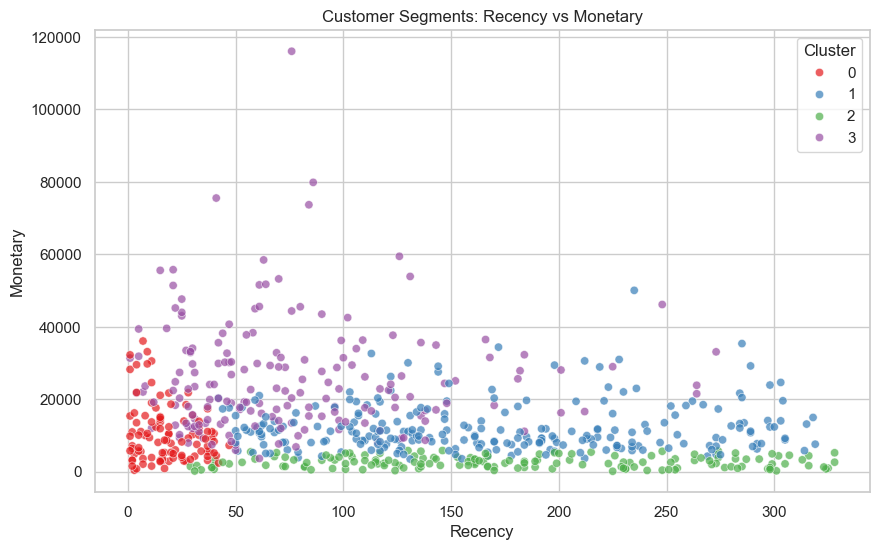

In [6]:
# Apply KMeans with k=4 (Assuming elbow at 4 based on typical RFM)
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

display(cluster_summary)

# Visualizing Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Customer Segments: Recency vs Monetary')
plt.show()

### Customer Segment Interpretations

**Scatter Plot**: Highlighting Recency against Monetary colored by Cluster helps visualize distinct groupings. We expect at least one tight low-value cluster with high recency and another diffuse cluster of recent high-spenders.

## 6. Cluster Interpretation

Based on common RFM patterns:

- **Cluster 0 (At-Risk / Churned)**: Customers who have not purchased recently, with low purchase frequency and low spending.  
- **Cluster 1 (High Value Loyal)**: Customers who purchased recently, buy frequently, and spend the most.  
- **Cluster 2 (Occasional / Promising)**: Customers with moderate purchase activity and spending behavior.  
- **Cluster 3 (New or Recent Low Spenders)**: Recent customers with low purchase frequency and lower spending.  

*(Note: Final interpretations may vary based on the `cluster_summary` mean values.)*

## 7. Business Recommendations

1. **High Value Loyal Customers**: Offer loyalty rewards, exclusive deals, and personalized product recommendations.  

2. **At-Risk / Churned Customers**: Run re-engagement campaigns using discounts or personalized reminder emails.  

3. **Occasional / Promising Customers**: Use targeted promotions, upselling, and bundle offers to encourage more purchases.  

4. **Recent Low Spenders**: Support them with welcome emails and special offers to encourage repeat purchases.